# Decision Boundary: CSF Amyloid vs. Phosphorylated Tau

A single, focused visual: fit Logistic Regression on the two biomarkers `logistic_regression_pipeline.ipynb`'s search lands on, using the same hyperparameters (`C=10`, no class weighting), and plot the resulting decision boundary directly in amyloid/tau space. This is the plot embedded in `README.md`'s Data Understanding section.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from matplotlib.colors import ListedColormap

# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
df = mci.copy()
df = df.rename(columns={'CSF Amyloid (pg/mL)': 'amyloid', 'CSF Phosphorylated tau (pg/mL)': 'tau', "Progression to Alzheimer's Disease" : 'progression'})

/home/fazuskazoo/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


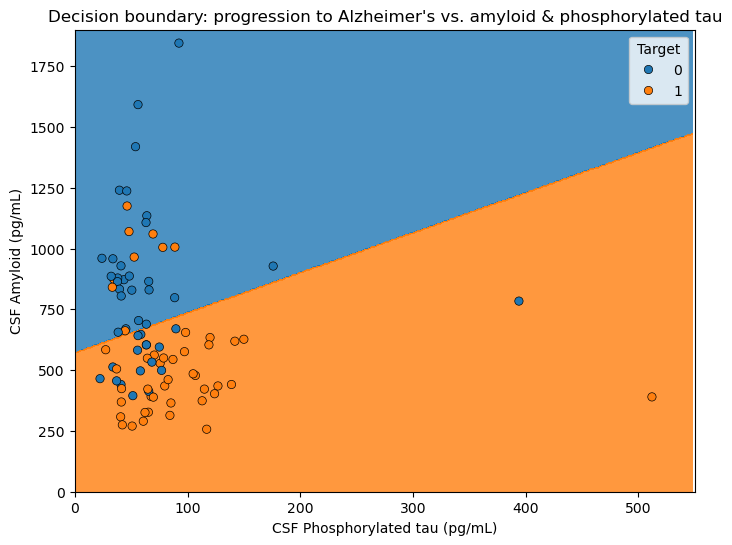

In [24]:
sns_cmap = ListedColormap(np.array(sns.color_palette())[0:2, :])

xx, yy = np.meshgrid(np.arange(0, 550, 2),
                      np.arange(0, 1900, 5))

Z = logistic_regression_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=sns_cmap, alpha=0.8)
sns.scatterplot(data=df, x="tau", y="amyloid", hue="Target", edgecolor='black')
plt.xlim(0, 550)
plt.ylim(0, 1900)
plt.xlabel('CSF Phosphorylated tau (pg/mL)')
plt.ylabel('CSF Amyloid (pg/mL)')
plt.title("Decision boundary: progression to Alzheimer's vs. amyloid & phosphorylated tau")
plt.savefig("images/decision_boundary.png", dpi=300, bbox_inches="tight")
plt.show()